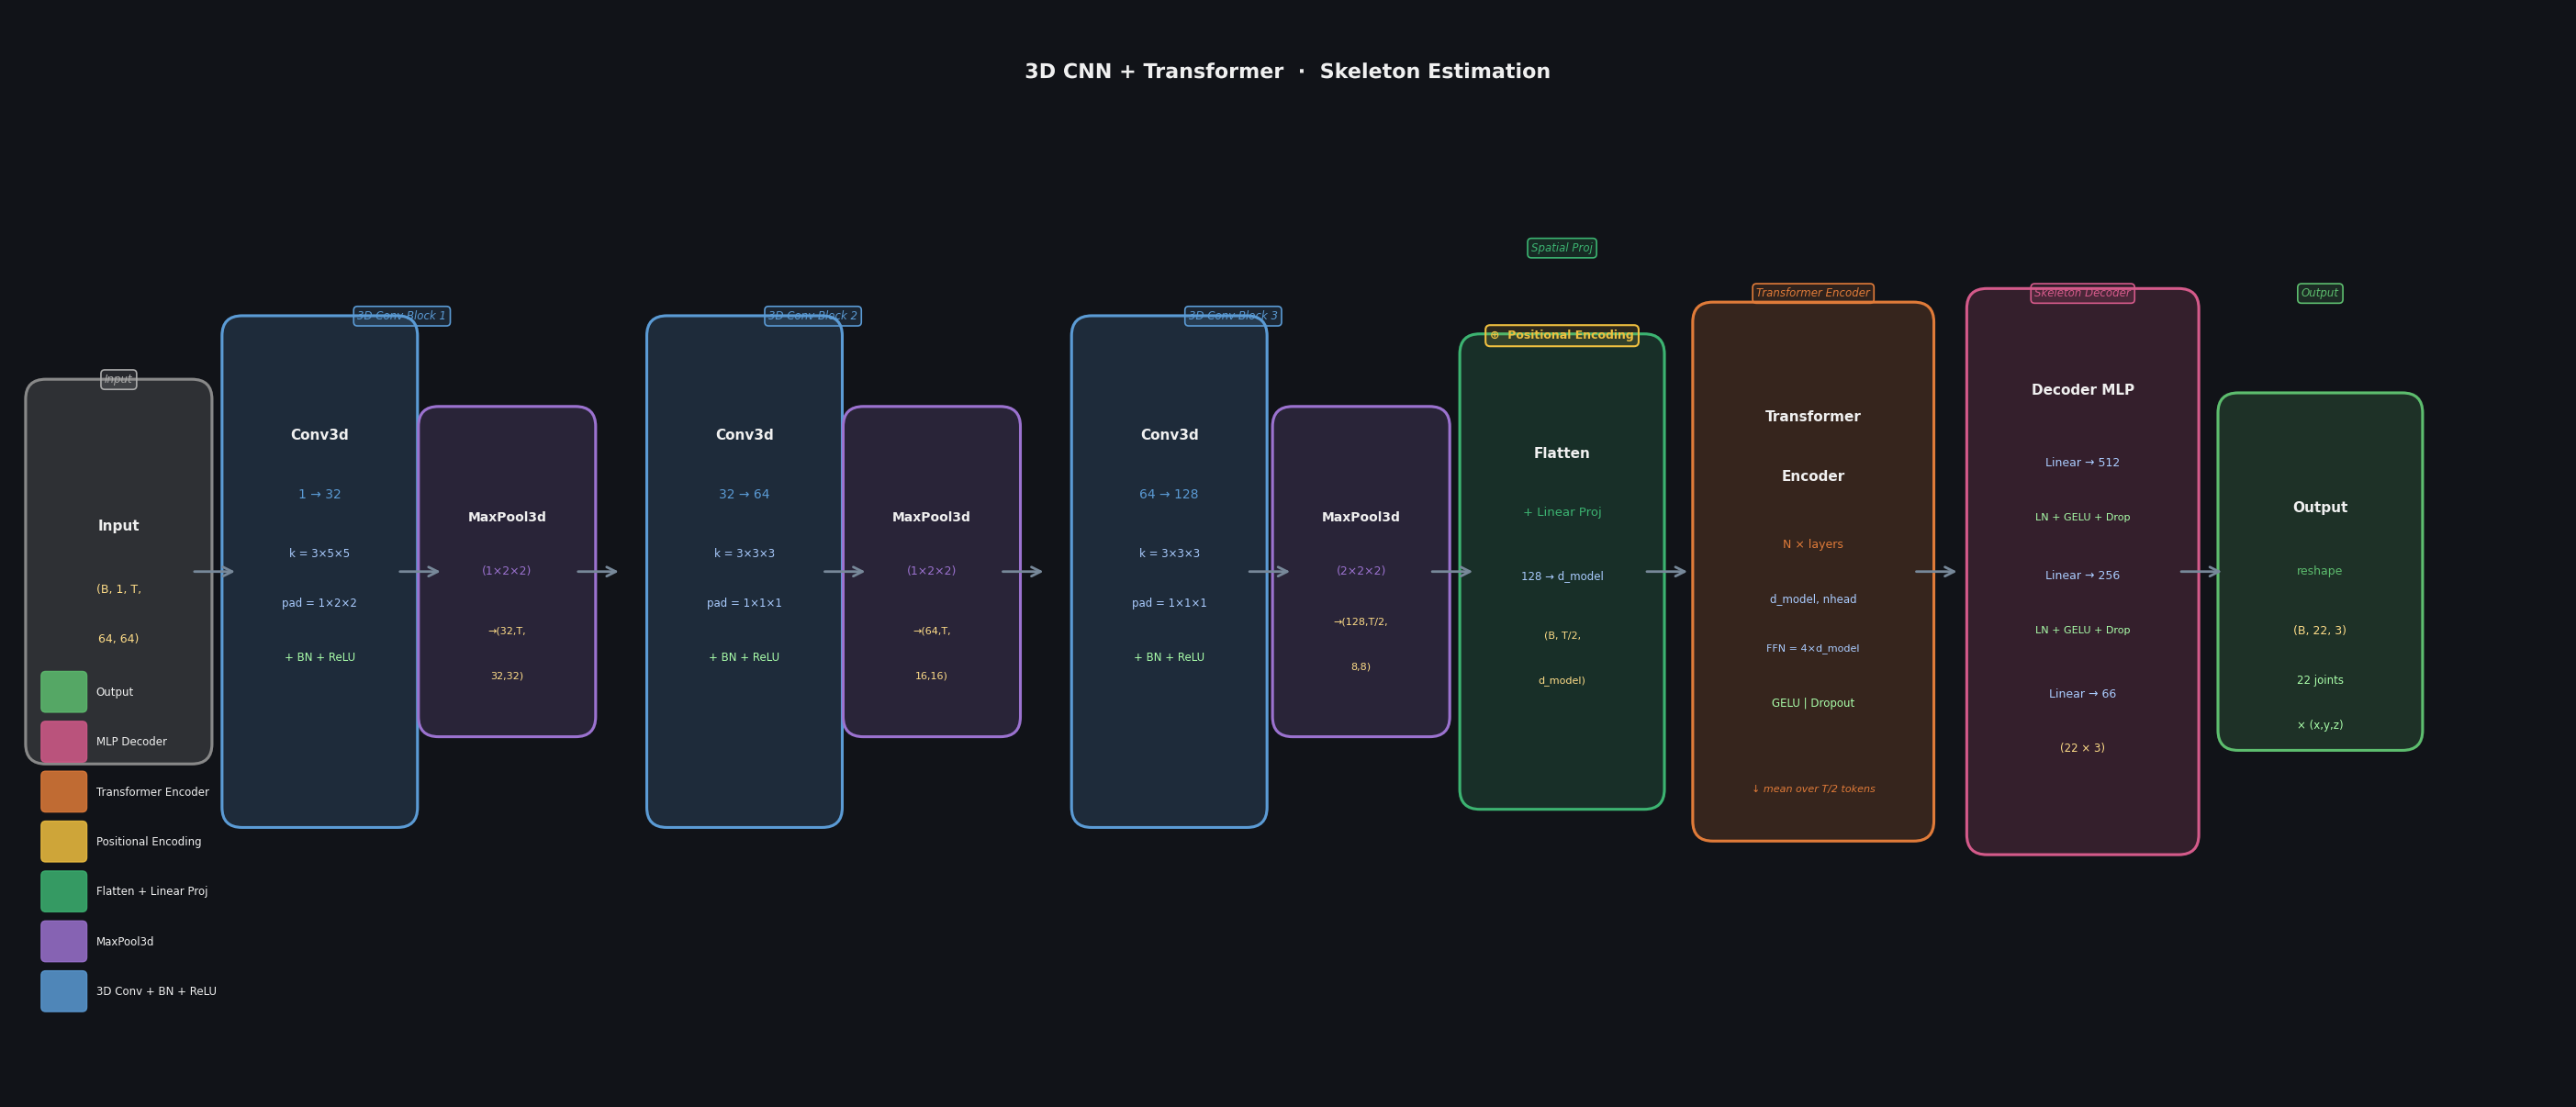

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np

# ── Canvas ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(28, 12))
ax.set_xlim(0, 28)
ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor('#111318')
ax.set_facecolor('#111318')

# ── Palette ─────────────────────────────────────────────────────────────────
DARK   = '#111318'
C_CONV  = '#5B9BD5'
C_POOL  = '#9B72CF'
C_PROJ  = '#3CB371'
C_PE    = '#F0C040'
C_TRANS = '#E07B39'
C_DEC   = '#D45A8A'
C_OUT   = '#5DBD6E'
C_TEXT  = '#F0F0F0'
C_SUB   = '#AACCFF'
C_DIM   = '#FFDD88'

# ── Helpers ─────────────────────────────────────────────────────────────────
def rounded_box(ax, cx, cy, w, h, color, alpha_fill=0.18, lw=2.2, radius=0.22):
    rect = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                          boxstyle=f"round,pad={radius}",
                          linewidth=lw, edgecolor=color,
                          facecolor=color, alpha=alpha_fill, zorder=3)
    ax.add_patch(rect)
    # brighter border
    border = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                             boxstyle=f"round,pad={radius}",
                             linewidth=lw, edgecolor=color,
                             facecolor='none', zorder=4)
    ax.add_patch(border)

def label(ax, x, y, text, size=10, color=C_TEXT, bold=False, zorder=5):
    weight = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center', color=color,
            fontsize=size, fontweight=weight, zorder=zorder,
            multialignment='center')

def arrow(ax, x1, x2, y, color='#778899', lw=2):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, mutation_scale=18),
                zorder=5)

def section_tag(ax, cx, cy_top, text, color):
    ax.text(cx, cy_top, text, ha='center', va='bottom',
            color=color, fontsize=8.5, style='italic', zorder=5,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=color+'25',
                      edgecolor=color, linewidth=1.2))

# ── Layout constants ─────────────────────────────────────────────────────────
Y     = 5.8       # center Y of all main blocks
TAG_Y = Y + 3.5   # section tag Y

# ── 1. INPUT ─────────────────────────────────────────────────────────────────
cx = 1.2
rounded_box(ax, cx, Y, 1.6, 3.8, '#888888', alpha_fill=0.25)
label(ax, cx, Y+0.5,  'Input',        size=11, bold=True)
label(ax, cx, Y-0.2,  '(B, 1, T,',   size=9,  color=C_DIM)
label(ax, cx, Y-0.75, '64, 64)',      size=9,  color=C_DIM)
section_tag(ax, cx, Y+2.05, 'Input', '#AAAAAA')

# ── 2. CONV BLOCK 1 ──────────────────────────────────────────────────────────
arrow(ax, 2.0, 2.5, Y)

cx = 3.4
rounded_box(ax, cx, Y, 1.7, 5.2, C_CONV)
label(ax, cx, Y+1.5,  'Conv3d',        size=11, bold=True,  color=C_TEXT)
label(ax, cx, Y+0.85, '1 → 32',        size=10, color=C_CONV)
label(ax, cx, Y+0.2,  'k = 3×5×5',    size=8.5,color=C_SUB)
label(ax, cx, Y-0.35, 'pad = 1×2×2',  size=8.5,color=C_SUB)
label(ax, cx, Y-0.95, '+ BN + ReLU',  size=8.5,color='#AAFFAA')

arrow(ax, 4.25, 4.75, Y)

cx2 = 5.45
rounded_box(ax, cx2, Y, 1.5, 3.2, C_POOL)
label(ax, cx2, Y+0.6,  'MaxPool3d',   size=10, bold=True, color=C_TEXT)
label(ax, cx2, Y+0.0,  '(1×2×2)',     size=9,  color=C_POOL)
label(ax, cx2, Y-0.65, '→(32,T,',    size=8,  color=C_DIM)
label(ax, cx2, Y-1.15, '32,32)',      size=8,  color=C_DIM)

section_tag(ax, 4.3, Y+2.75, '3D Conv Block 1', C_CONV)

# ── 3. CONV BLOCK 2 ──────────────────────────────────────────────────────────
arrow(ax, 6.2, 6.7, Y)

cx = 8.05
rounded_box(ax, cx, Y, 1.7, 5.2, C_CONV)
label(ax, cx, Y+1.5,  'Conv3d',        size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+0.85, '32 → 64',       size=10, color=C_CONV)
label(ax, cx, Y+0.2,  'k = 3×3×3',    size=8.5,color=C_SUB)
label(ax, cx, Y-0.35, 'pad = 1×1×1',  size=8.5,color=C_SUB)
label(ax, cx, Y-0.95, '+ BN + ReLU',  size=8.5,color='#AAFFAA')

arrow(ax, 8.9, 9.4, Y)

cx2 = 10.1
rounded_box(ax, cx2, Y, 1.5, 3.2, C_POOL)
label(ax, cx2, Y+0.6,  'MaxPool3d',   size=10, bold=True, color=C_TEXT)
label(ax, cx2, Y+0.0,  '(1×2×2)',     size=9,  color=C_POOL)
label(ax, cx2, Y-0.65, '→(64,T,',    size=8,  color=C_DIM)
label(ax, cx2, Y-1.15, '16,16)',      size=8,  color=C_DIM)

section_tag(ax, 8.8, Y+2.75, '3D Conv Block 2', C_CONV)

# ── 4. CONV BLOCK 3 ──────────────────────────────────────────────────────────
arrow(ax, 10.85, 11.35, Y)

cx = 12.7
rounded_box(ax, cx, Y, 1.7, 5.2, C_CONV)
label(ax, cx, Y+1.5,  'Conv3d',        size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+0.85, '64 → 128',      size=10, color=C_CONV)
label(ax, cx, Y+0.2,  'k = 3×3×3',    size=8.5,color=C_SUB)
label(ax, cx, Y-0.35, 'pad = 1×1×1',  size=8.5,color=C_SUB)
label(ax, cx, Y-0.95, '+ BN + ReLU',  size=8.5,color='#AAFFAA')

arrow(ax, 13.55, 14.05, Y)

cx2 = 14.8
rounded_box(ax, cx2, Y, 1.5, 3.2, C_POOL)
label(ax, cx2, Y+0.6,  'MaxPool3d',    size=10, bold=True, color=C_TEXT)
label(ax, cx2, Y+0.0,  '(2×2×2)',      size=9,  color=C_POOL)
label(ax, cx2, Y-0.55, '→(128,T/2,',  size=8,  color=C_DIM)
label(ax, cx2, Y-1.05, '8,8)',         size=8,  color=C_DIM)

section_tag(ax, 13.4, Y+2.75, '3D Conv Block 3', C_CONV)

# ── 5. FLATTEN + PROJ ────────────────────────────────────────────────────────
arrow(ax, 15.55, 16.05, Y)

cx = 17.0
rounded_box(ax, cx, Y, 1.8, 4.8, C_PROJ)
label(ax, cx, Y+1.3,  'Flatten',        size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+0.65, '+ Linear Proj',  size=9.5,color=C_PROJ)
label(ax, cx, Y-0.05, '128 → d_model', size=8.5,color=C_SUB)
label(ax, cx, Y-0.7,  '(B, T/2,',      size=8,  color=C_DIM)
label(ax, cx, Y-1.2,  'd_model)',       size=8,  color=C_DIM)

# Pos Enc badge
ax.text(cx, Y+2.6, '⊕  Positional Encoding', ha='center', va='center',
        color=C_PE, fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=C_PE+'20',
                  edgecolor=C_PE, linewidth=1.5), zorder=6)

section_tag(ax, cx, Y+2.55, '', C_PROJ)  # placeholder spacing
ax.text(cx, TAG_Y, 'Spatial Proj', ha='center', va='bottom',
        color=C_PROJ, fontsize=8.5, style='italic',
        bbox=dict(boxstyle='round,pad=0.35', facecolor=C_PROJ+'25',
                  edgecolor=C_PROJ, linewidth=1.2), zorder=5)

# ── 6. TRANSFORMER ───────────────────────────────────────────────────────────
arrow(ax, 17.9, 18.4, Y)

cx = 19.75
rounded_box(ax, cx, Y, 2.2, 5.5, C_TRANS)
label(ax, cx, Y+1.7,  'Transformer',    size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+1.05, 'Encoder',        size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+0.3,  'N × layers',     size=9,  color=C_TRANS)
label(ax, cx, Y-0.3,  'd_model, nhead', size=8.5,color=C_SUB)
label(ax, cx, Y-0.85, 'FFN = 4×d_model',size=8, color=C_SUB)
label(ax, cx, Y-1.45, 'GELU | Dropout', size=8.5,color='#AAFFAA')
ax.text(cx, Y-2.4, '↓ mean over T/2 tokens', ha='center', va='center',
        color=C_TRANS, fontsize=8, style='italic', zorder=5)

section_tag(ax, cx, TAG_Y - 0.5, 'Transformer Encoder', C_TRANS)

# ── 7. DECODER ───────────────────────────────────────────────────────────────
arrow(ax, 20.85, 21.35, Y)

cx = 22.7
rounded_box(ax, cx, Y, 2.1, 5.8, C_DEC)
label(ax, cx, Y+2.0,  'Decoder MLP',    size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+1.2,  'Linear → 512',   size=9,  color=C_SUB)
label(ax, cx, Y+0.6,  'LN + GELU + Drop',size=8, color='#AAFFAA')
label(ax, cx, Y-0.05, 'Linear → 256',   size=9,  color=C_SUB)
label(ax, cx, Y-0.65, 'LN + GELU + Drop',size=8, color='#AAFFAA')
label(ax, cx, Y-1.35, 'Linear → 66',    size=9,  color=C_SUB)
label(ax, cx, Y-1.95, '(22 × 3)',        size=8.5,color=C_DIM)

section_tag(ax, cx, TAG_Y - 0.5, 'Skeleton Decoder', C_DEC)

# ── 8. OUTPUT ────────────────────────────────────────────────────────────────
arrow(ax, 23.75, 24.25, Y)

cx = 25.3
rounded_box(ax, cx, Y, 1.8, 3.5, C_OUT)
label(ax, cx, Y+0.7,  'Output',       size=11, bold=True, color=C_TEXT)
label(ax, cx, Y+0.0,  'reshape',      size=9,  color=C_OUT)
label(ax, cx, Y-0.65, '(B, 22, 3)',   size=9,  color=C_DIM)
label(ax, cx, Y-1.2,  '22 joints',    size=8.5,color='#AAFFAA')
label(ax, cx, Y-1.7,  '× (x,y,z)',   size=8.5,color='#AAFFAA')

section_tag(ax, cx, TAG_Y - 0.5, 'Output', C_OUT)

# ── LEGEND ───────────────────────────────────────────────────────────────────
legend_data = [
    (C_CONV,  '3D Conv + BN + ReLU'),
    (C_POOL,  'MaxPool3d'),
    (C_PROJ,  'Flatten + Linear Proj'),
    (C_PE,    'Positional Encoding'),
    (C_TRANS, 'Transformer Encoder'),
    (C_DEC,   'MLP Decoder'),
    (C_OUT,   'Output'),
]
for i, (c, lbl) in enumerate(legend_data):
    bx, by = 0.4, 1.0 + i * 0.55
    ax.add_patch(mpatches.FancyBboxPatch((bx, by), 0.4, 0.35,
                 boxstyle='round,pad=0.05', color=c, alpha=0.85, zorder=5))
    ax.text(bx + 0.55, by + 0.17, lbl, color=C_TEXT,
            fontsize=8.5, va='center', zorder=5)

# ── TITLE ────────────────────────────────────────────────────────────────────
ax.text(14, 11.3, '3D CNN + Transformer  ·  Skeleton Estimation',
        ha='center', va='center', color=C_TEXT, fontsize=16,
        fontweight='bold',
        path_effects=[pe.withStroke(linewidth=4, foreground=DARK)])

plt.tight_layout(pad=0.5)
plt.savefig('architecture_v2.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()